In [34]:
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

In [9]:
def definithion_trestbps_mean(age, sex):
    if sex == 1:
        if age == 20:
            return '123/76'
        elif age > 20 and age <= 30:
            return '126/79'
        elif age >= 31 and age <= 40:
            return '129/81'
        elif age >= 41 and age <= 50:
            return '135/83'
        elif age >= 51 and age <= 60:
            return '142/85'
        elif age >= 61:
            return '142/80'
    elif sex == 0:
        if age == 20:
            return '116/72'
        elif age > 20 and age <= 30:
            return '120/75'
        elif age >= 31 and age <= 40:
            return '127/80'
        elif age >= 41 and age <= 50:
            return '137/84'
        elif age >= 51 and age <= 60:
            return '144/85'
        elif age >= 61:
            return '169/85'

In [2]:
heart_data = pd.read_csv('data/heart.csv')

In [3]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
heart_data['old'] = heart_data['age'].apply(lambda x: 1 if x > 60 else 0)

heart_data['old'].sum()

79

In [15]:
heart_data['trestbps_mean'] = heart_data.apply(lambda x: definithion_trestbps_mean(x[0], x[1]), axis=1)

heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old,trestbps_mean
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1,142/80
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0,129/81
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0,137/84
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0,142/85
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0,144/85


In [18]:
heart_data.loc[300, 'trestbps_mean']

'142/80'

In [23]:
encoder = ce.OneHotEncoder(cols=['cp', 'restecg', 'slope', 'ca', 'thal'])
ohe_data = encoder.fit_transform(heart_data[['cp', 'restecg', 'slope', 'ca', 'thal']])
heart_data = pd.concat([heart_data, ohe_data], axis=1)

heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,slope_3,ca_1,ca_2,ca_3,ca_4,ca_5,thal_1,thal_2,thal_3,thal_4
0,63,1,3,145,233,1,0,150,0,2.3,...,0,1,0,0,0,0,1,0,0,0
1,37,1,2,130,250,0,1,187,0,3.5,...,0,1,0,0,0,0,0,1,0,0
2,41,0,1,130,204,0,0,172,0,1.4,...,0,1,0,0,0,0,0,1,0,0
3,56,1,1,120,236,0,1,178,0,0.8,...,0,1,0,0,0,0,0,1,0,0
4,57,0,0,120,354,0,1,163,1,0.6,...,0,1,0,0,0,0,0,1,0,0


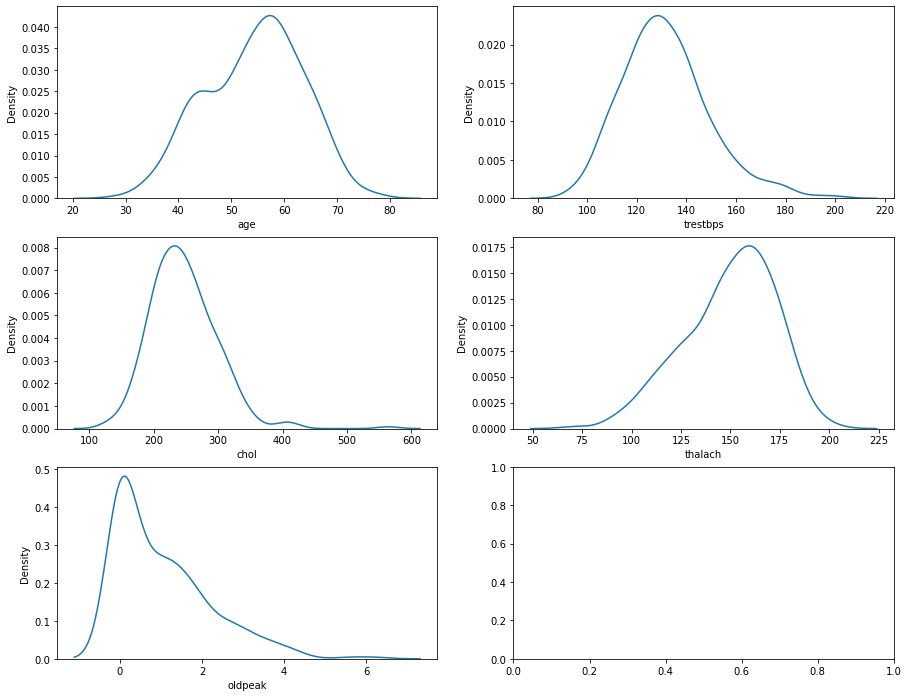

In [33]:
# зададим параметры холста, название и визуализируем кривые распределения:
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(15, 12))

sns.kdeplot(heart_data['age'], ax=axes[0, 0], label ='age')
sns.kdeplot(heart_data['trestbps'], ax=axes[0, 1], label ='trestbps')
sns.kdeplot(heart_data['chol'], ax=axes[1, 0], label ='chol')
sns.kdeplot(heart_data['thalach'], ax=axes[1, 1], label ='thalach')
sns.kdeplot(heart_data['oldpeak'], ax=axes[2, 0], label ='oldpeak');

In [36]:
mm_scaler = preprocessing.MinMaxScaler(copy=False)

heart_data[['age', 'trestbps', 'thalach']] = mm_scaler.fit_transform(heart_data[['age', 'trestbps', 'thalach']])

In [38]:
r_scaler = preprocessing.RobustScaler(copy=False)

heart_data[['chol', 'oldpeak']] = r_scaler.fit_transform(heart_data[['chol', 'oldpeak']])

In [39]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,slope_3,ca_1,ca_2,ca_3,ca_4,ca_5,thal_1,thal_2,thal_3,thal_4
0,0.708333,1,3,0.481132,-0.110236,1,0,0.603053,0,0.9375,...,0,1,0,0,0,0,1,0,0,0
1,0.166667,1,2,0.339623,0.157480,0,1,0.885496,0,1.6875,...,0,1,0,0,0,0,0,1,0,0
2,0.250000,0,1,0.339623,-0.566929,0,0,0.770992,0,0.3750,...,0,1,0,0,0,0,0,1,0,0
3,0.562500,1,1,0.245283,-0.062992,0,1,0.816794,0,0.0000,...,0,1,0,0,0,0,0,1,0,0
4,0.583333,0,0,0.245283,1.795276,0,1,0.702290,1,-0.1250,...,0,1,0,0,0,0,0,1,0,0


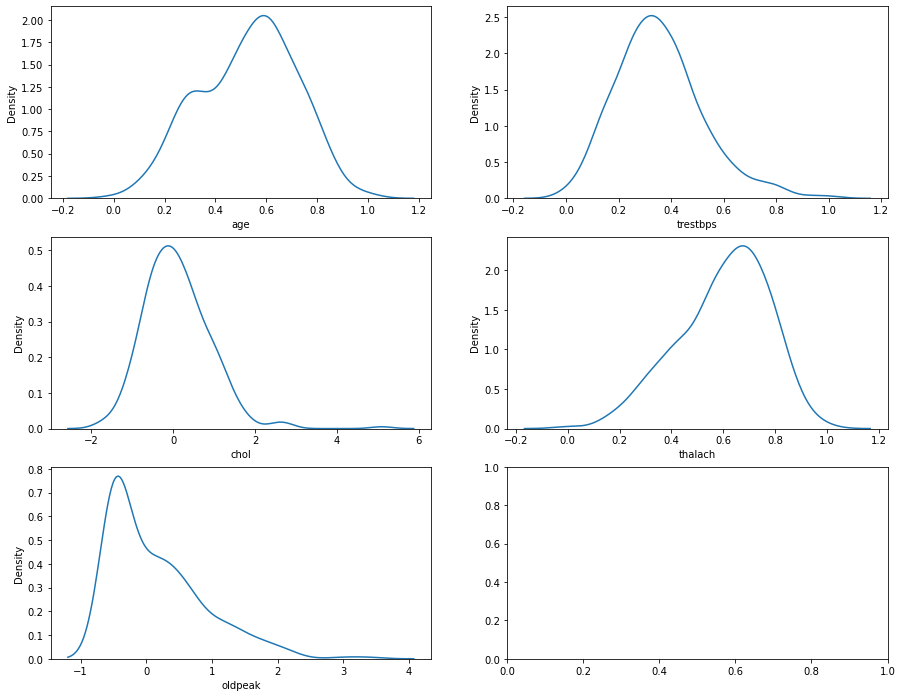

In [40]:
# зададим параметры холста, название и визуализируем кривые распределения:
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(15, 12))

sns.kdeplot(heart_data['age'], ax=axes[0, 0], label ='age')
sns.kdeplot(heart_data['trestbps'], ax=axes[0, 1], label ='trestbps')
sns.kdeplot(heart_data['chol'], ax=axes[1, 0], label ='chol')
sns.kdeplot(heart_data['thalach'], ax=axes[1, 1], label ='thalach')
sns.kdeplot(heart_data['oldpeak'], ax=axes[2, 0], label ='oldpeak');

In [42]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,slope_3,ca_1,ca_2,ca_3,ca_4,ca_5,thal_1,thal_2,thal_3,thal_4
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,...,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,0.528465,0.683168,0.966997,0.354941,0.098646,0.148515,0.528053,0.600358,0.326733,0.149752,...,0.462046,0.577558,0.125413,0.214521,0.066007,0.016502,0.059406,0.547855,0.386139,0.006601
std,0.189210,0.466011,1.032052,0.165454,0.816232,0.356198,0.525860,0.174849,0.469794,0.725672,...,0.499382,0.494765,0.331734,0.411169,0.248704,0.127605,0.236774,0.498528,0.487668,0.081110
min,0.000000,0.000000,0.000000,0.000000,-1.795276,0.000000,0.000000,0.000000,0.000000,-0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.385417,0.000000,0.000000,0.245283,-0.456693,0.000000,0.000000,0.477099,0.000000,-0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.541667,1.000000,1.000000,0.339623,0.000000,0.000000,1.000000,0.625954,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.666667,1.000000,2.000000,0.433962,0.543307,0.000000,1.000000,0.725191,1.000000,0.500000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,3.000000,1.000000,5.102362,1.000000,2.000000,1.000000,1.000000,3.375000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


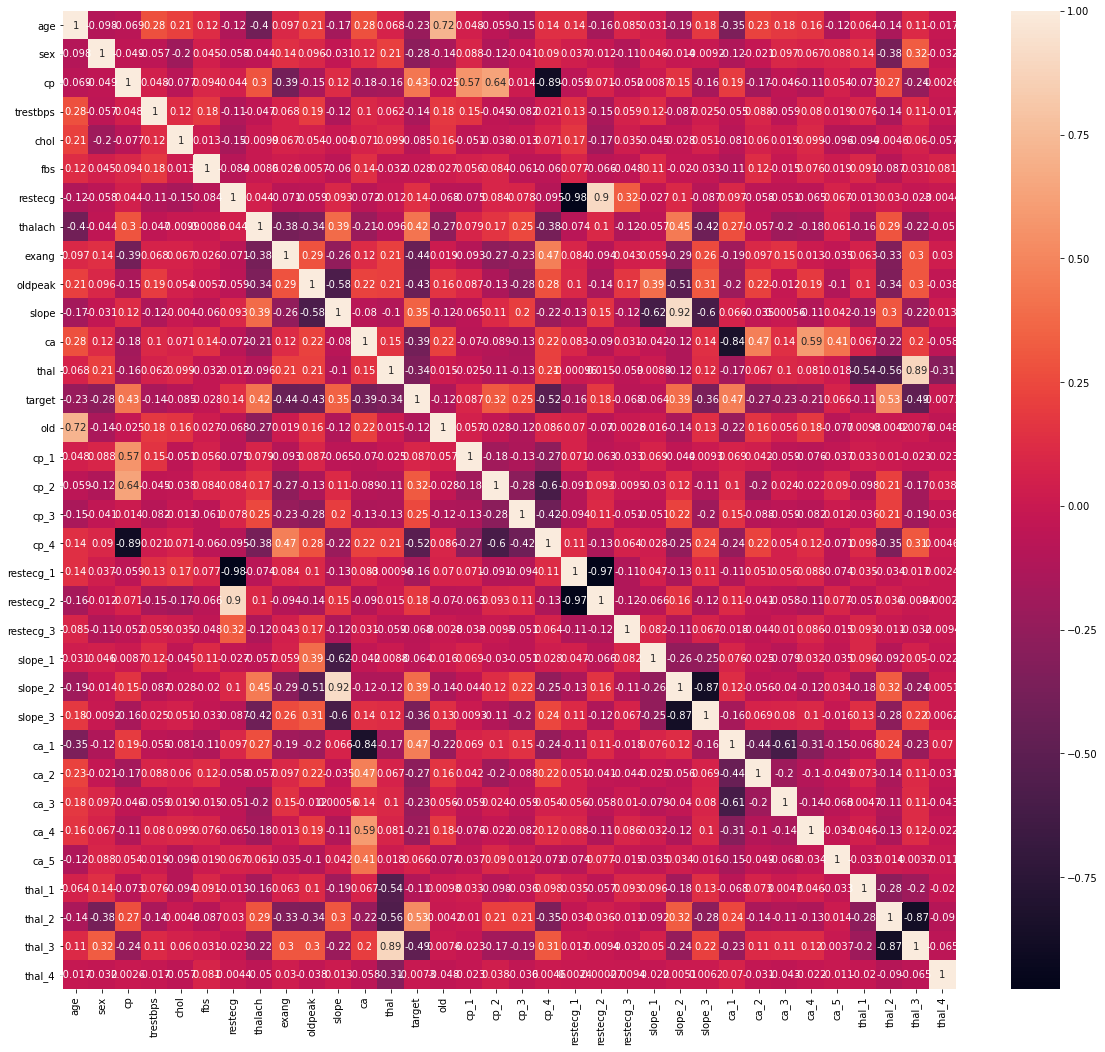

In [45]:
fig = plt.figure(figsize=(20, 18))

heat_map = sns.heatmap(heart_data.corr(), annot=True);